# Predicción de aprobación de créditos mediante Machine Learning

## Maestría en Tecnologías de la Información
### Big Data, Analytics & Data Scientist

**Estudiante:** Gustavo Vaca

**Tema:** Análisis predictivo para aprobación de créditos bancarios

**Fecha:** Junio 2026

# Tabla de Contenido

1. Introducción
2. Problemática
3. Objetivos
4. Descripción del Dataset
5. Diccionario de Variables
6. Pipeline del Proyecto
7. Carga de Librerías
8. Carga de Datos
9. Limpieza y Preparación
10.

# Introducción

La transformación digital ha impulsado la adopción de técnicas de analítica avanzada y Machine Learning dentro del sector financiero. Las instituciones bancarias requieren herramientas que permitan optimizar la evaluación de solicitudes de crédito, reducir riesgos y mejorar la eficiencia operativa.

En este proyecto se desarrolla un análisis exploratorio de datos (EDA) y un modelo predictivo utilizando Random Forest para identificar los factores que influyen en la aprobación de créditos bancarios.

# Problemática

La evaluación crediticia tradicional puede requerir tiempos elevados de análisis y estar expuesta a errores humanos.

Por ello, las instituciones financieras buscan utilizar técnicas de análisis de datos y Machine Learning para apoyar la toma de decisiones, identificar clientes con mayor probabilidad de aprobación y optimizar la gestión del riesgo crediticio.

# Objetivo General

Desarrollar un modelo predictivo que permita estimar la aprobación de créditos mediante técnicas de análisis de datos y Machine Learning.

# Objetivos Específicos

- Analizar la calidad y estructura del dataset.
- Aplicar técnicas de limpieza y transformación de datos.
- Realizar análisis exploratorio

In [1]:
import pandas as pd
import numpy as np

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
import pandas as pd

df = pd.read_excel(
    r"C:\Users\ASUS\Downloads\creditos_bancarios_5000.xlsx"
)

df.head()

,id_cliente,fecha_solicitud,edad,genero,estado_civil,ciudad,ingresos_mensuales,gastos_mensuales,score_crediticio,antiguedad_laboral,tipo_empleo,monto_solicitado,plazo_meses,productos_bancarios,mora_historica,canal_solicitud,capacidad_pago,credito_aprobado
0,1,2024-04-26,66,Masculino,Casado,Manta,2626,3087,715,24,Privado,47581,48,2,Si,Movil,-461,0
1,2,2023-04-26,29,Femenino,Divorciado,Guayaquil,861,561,434,1,Privado,29226,48,4,Si,Web,300,0
2,3,2025-01-20,28,Femenino,Divorciado,Ambato,3095,2657,659,8,Dependiente,46405,60,4,No,Movil,438,1
3,4,2023-01-07,60,Masculino,Divorciado,Quito,5642,3610,472,21,Dependiente,33362,48,1,No,Agencia,2032,1
4,5,2024-04-12,41,Masculino,Casado,Quito,1463,2481,392,17,Privado,12010,48,3,No,Agencia,-1018,0


In [3]:
df.shape

(5000, 18)

In [4]:
df.columns

Index(['id_cliente', 'fecha_solicitud', 'edad', 'genero', 'estado_civil',
       'ciudad', 'ingresos_mensuales', 'gastos_mensuales', 'score_crediticio',
       'antiguedad_laboral', 'tipo_empleo', 'monto_solicitado', 'plazo_meses',
       'productos_bancarios', 'mora_historica', 'canal_solicitud',
       'capacidad_pago', 'credito_aprobado'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   id_cliente           5000 non-null   int64
 1   fecha_solicitud      5000 non-null   str  
 2   edad                 5000 non-null   int64
 3   genero               5000 non-null   str  
 4   estado_civil         5000 non-null   str  
 5   ciudad               5000 non-null   str  
 6   ingresos_mensuales   5000 non-null   int64
 7   gastos_mensuales     5000 non-null   int64
 8   score_crediticio     5000 non-null   int64
 9   antiguedad_laboral   5000 non-null   int64
 10  tipo_empleo          5000 non-null   str  
 11  monto_solicitado     5000 non-null   int64
 12  plazo_meses          5000 non-null   int64
 13  productos_bancarios  5000 non-null   int64
 14  mora_historica       5000 non-null   str  
 15  canal_solicitud      5000 non-null   str  
 16  capacidad_pago       5000 non-null 

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   id_cliente           5000 non-null   int64
 1   fecha_solicitud      5000 non-null   str  
 2   edad                 5000 non-null   int64
 3   genero               5000 non-null   str  
 4   estado_civil         5000 non-null   str  
 5   ciudad               5000 non-null   str  
 6   ingresos_mensuales   5000 non-null   int64
 7   gastos_mensuales     5000 non-null   int64
 8   score_crediticio     5000 non-null   int64
 9   antiguedad_laboral   5000 non-null   int64
 10  tipo_empleo          5000 non-null   str  
 11  monto_solicitado     5000 non-null   int64
 12  plazo_meses          5000 non-null   int64
 13  productos_bancarios  5000 non-null   int64
 14  mora_historica       5000 non-null   str  
 15  canal_solicitud      5000 non-null   str  
 16  capacidad_pago       5000 non-null 

In [7]:
df.describe()

,id_cliente,edad,ingresos_mensuales,gastos_mensuales,score_crediticio,antiguedad_laboral,monto_solicitado,plazo_meses,productos_bancarios,capacidad_pago,credito_aprobado
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,43.856800,3260.394000,2158.596800,600.468000,14.923800,25625.072200,36.067200,3.978200,1101.797200,0.530000
std,1443.520003,15.131308,1585.620856,1076.659505,172.314603,8.787482,14335.462955,17.056778,1.995325,1939.255606,0.499149
min,1.000000,18.000000,500.000000,301.000000,300.000000,0.000000,1003.000000,12.000000,1.000000,-3457.000000,0.000000
25%,1250.750000,31.000000,1891.000000,1231.750000,452.000000,8.000000,12885.750000,24.000000,2.000000,-314.500000,0.000000
50%,2500.500000,44.000000,3258.500000,2168.500000,603.000000,15.000000,25793.000000,36.000000,4.000000,1120.000000,1.000000
75%,3750.250000,57.000000,4619.000000,3072.000000,750.000000,22.000000,38304.500000,48.000000,6.000000,2496.000000,1.000000
max,5000.000000,69.000000,6000.000000,4000.000000,900.000000,30.000000,49998.000000,60.000000,7.000000,5554.000000,1.000000


In [8]:
df.describe(include='object')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_10000\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,fecha_solicitud,genero,estado_civil,ciudad,tipo_empleo,mora_historica,canal_solicitud
count,5000,5000,5000,5000,5000,5000,5000
unique,1085,2,4,6,4,2,3
top,2024-02-27,Femenino,Soltero,Cuenca,Independiente,No,Web
freq,13,2523,1307,872,1268,3756,1691


# Descripción del Dataset

El dataset utilizado contiene información de 5.000 solicitudes de crédito bancario.

La información incluye variables demográficas, financieras y crediticias que permiten analizar los factores asociados a la aprobación de créditos.

El conjunto de datos contiene 18 variables, incluyendo una variable objetivo denominada "credito_aprobado", utilizada para el desarrollo del modelo de clasificación.

# Diccionario de Variables

| Variable | Tipo | Descripción |
|-----------|-----------|-----------|
| id_cliente | Numérica | Identificador único |
| fecha_solicitud | Fecha | Fecha de solicitud |
| edad | Numérica | Edad del cliente |
| genero | Categórica | Género del cliente |
| estado_civil | Categórica | Estado civil |
| ciudad | Categórica | Ciudad de residencia |
| ingresos_mensuales | Numérica | Ingresos mensuales |
| gastos_mensuales | Numérica | Gastos mensuales |
| score_crediticio | Numérica | Puntaje crediticio |
| antiguedad_laboral | Numérica | Años de experiencia laboral |
| tipo_empleo | Categórica | Tipo de empleo |
| monto_solicitado | Numérica | Monto solicitado |
| plazo_meses | Numérica | Plazo del crédito |
| productos_bancarios | Numérica | Productos financieros contratados |
| mora_historica | Categórica | Historial de mora |
| canal_solicitud | Categórica | Canal de solicitud |
| capacidad_pago | Numérica | Ingresos menos gastos |
| credito_aprobado | Objetivo | Resultado de aprobación |

# Pipeline del Proyecto

Carga de Datos
↓
Limpieza y Transformación
↓
Análisis Exploratorio (EDA)
↓
Visualización de Datos
↓
Preparación de Variables
↓
Entrenamiento del Modelo
↓
Evaluación del Modelo
↓
Interpretación de Resultados
↓
Conclusiones y Recomendaciones

# Limpieza y Preparación de Datos

In [9]:
df.isnull().sum()

id_cliente             0
fecha_solicitud        0
edad                   0
genero                 0
estado_civil           0
ciudad                 0
ingresos_mensuales     0
gastos_mensuales       0
score_crediticio       0
antiguedad_laboral     0
tipo_empleo            0
monto_solicitado       0
plazo_meses            0
productos_bancarios    0
mora_historica         0
canal_solicitud        0
capacidad_pago         0
credito_aprobado       0
dtype: int64

## Verificar duplicacion de datos

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['fecha_solicitud'] = pd.to_datetime(
    df['fecha_solicitud']
)

df.dtypes

id_cliente                      int64
fecha_solicitud        datetime64[us]
edad                            int64
genero                            str
estado_civil                      str
ciudad                            str
ingresos_mensuales              int64
gastos_mensuales                int64
score_crediticio                int64
antiguedad_laboral              int64
tipo_empleo                       str
monto_solicitado                int64
plazo_meses                     int64
productos_bancarios             int64
mora_historica                    str
canal_solicitud                   str
capacidad_pago                  int64
credito_aprobado                int64
dtype: object

In [12]:
df.nunique()

id_cliente             5000
fecha_solicitud        1085
edad                     52
genero                    2
estado_civil              4
ciudad                    6
ingresos_mensuales     3303
gastos_mensuales       2736
score_crediticio        601
antiguedad_laboral       31
tipo_empleo               4
monto_solicitado       4759
plazo_meses               5
productos_bancarios       7
mora_historica            2
canal_solicitud           3
capacidad_pago         3567
credito_aprobado          2
dtype: int64

In [13]:
df.describe()

,id_cliente,fecha_solicitud,edad,ingresos_mensuales,gastos_mensuales,score_crediticio,antiguedad_laboral,monto_solicitado,plazo_meses,productos_bancarios,capacidad_pago,credito_aprobado
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,2024-07-02 19:45:59.040000,43.856800,3260.394000,2158.596800,600.468000,14.923800,25625.072200,36.067200,3.978200,1101.797200,0.530000
min,1.000000,2023-01-01 00:00:00,18.000000,500.000000,301.000000,300.000000,0.000000,1003.000000,12.000000,1.000000,-3457.000000,0.000000
25%,1250.750000,2023-09-30 00:00:00,31.000000,1891.000000,1231.750000,452.000000,8.000000,12885.750000,24.000000,2.000000,-314.500000,0.000000
50%,2500.500000,2024-07-06 12:00:00,44.000000,3258.500000,2168.500000,603.000000,15.000000,25793.000000,36.000000,4.000000,1120.000000,1.000000
75%,3750.250000,2025-03-29 00:00:00,57.000000,4619.000000,3072.000000,750.000000,22.000000,38304.500000,48.000000,6.000000,2496.000000,1.000000
max,5000.000000,2025-12-31 00:00:00,69.000000,6000.000000,4000.000000,900.000000,30.000000,49998.000000,60.000000,7.000000,5554.000000,1.000000
std,1443.520003,NaN,15.131308,1585.620856,1076.659505,172.314603,8.787482,14335.462955,17.056778,1.995325,1939.255606,0.499149


### Interpretación

Se verificó la calidad de los datos mediante la revisión de valores nulos, registros duplicados y tipos de datos.

La variable fecha_solicitud fue transformada al formato datetime para permitir análisis temporales. Los datos presentan una estructura adecuada para realizar análisis exploratorio y modelado predictivo.

# Análisis Exploratorio de Datos

Se realizó un análisis exploratorio para comprender la distribución de las variables, identificar patrones y detectar relaciones entre variables financieras y crediticias.

Las visualizaciones permitieron identificar tendencias relevantes relacionadas con ingresos, score crediticio, capacidad de pago y comportamiento histórico de los clientes.

In [14]:
df['credito_aprobado'].value_counts()

credito_aprobado
1    2650
0    2350
Name: count, dtype: int64

In [15]:
df.groupby(
    'credito_aprobado'
)['ingresos_mensuales'].mean()

credito_aprobado
0    2632.780851
1    3816.956604
Name: ingresos_mensuales, dtype: float64

In [16]:
df.groupby(
    'credito_aprobado'
)['score_crediticio'].mean()

credito_aprobado
0    524.342979
1    667.975094
Name: score_crediticio, dtype: float64

In [17]:
df.groupby(
    'ciudad'
)['credito_aprobado'].mean()

ciudad
Ambato       0.533931
Cuenca       0.513761
Guayaquil    0.544811
Loja         0.558570
Manta        0.521688
Quito        0.508982
Name: credito_aprobado, dtype: float64

In [18]:
df.groupby(
    'genero'
)['credito_aprobado'].mean()

genero
Femenino     0.535870
Masculino    0.524021
Name: credito_aprobado, dtype: float64

Matplotlib is building the font cache; this may take a moment.


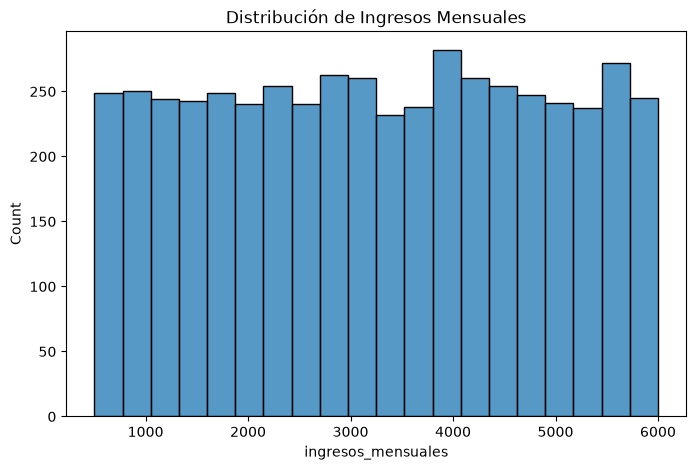

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    df['ingresos_mensuales'],
    bins=20
)

plt.title(
    'Distribución de Ingresos Mensuales'
)

plt.show()

### Interpretación

La distribución de ingresos permite identificar la concentración de clientes dentro de determinados rangos salariales.

In [20]:
### Interpretación

La distribución de ingresos permite identificar la concentración de clientes dentro de determinados rangos salariales.

SyntaxError: invalid syntax (2125252266.py, line 3)

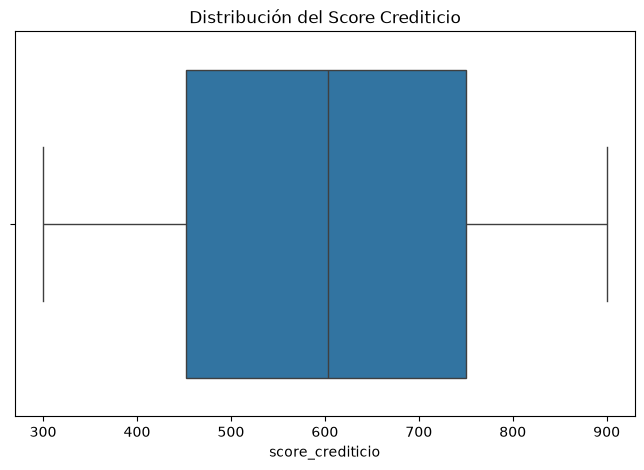

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['score_crediticio']
)

plt.title(
    'Distribución del Score Crediticio'
)

plt.show()

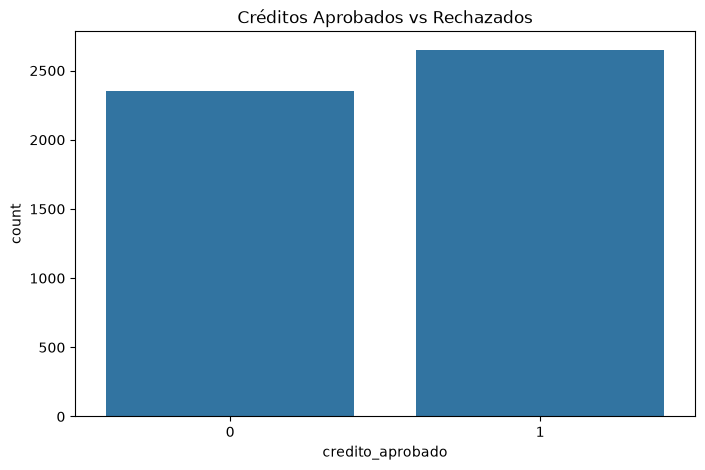

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='credito_aprobado',
    data=df
)

plt.title(
    'Créditos Aprobados vs Rechazados'
)

plt.show()

### Interpretación

Se observa una distribución relativamente equilibrada entre créditos aprobados y rechazados. Sin embargo, existe una ligera predominancia de créditos aprobados, lo que indica que la población analizada presenta características favorables para la obtención de financiamiento.

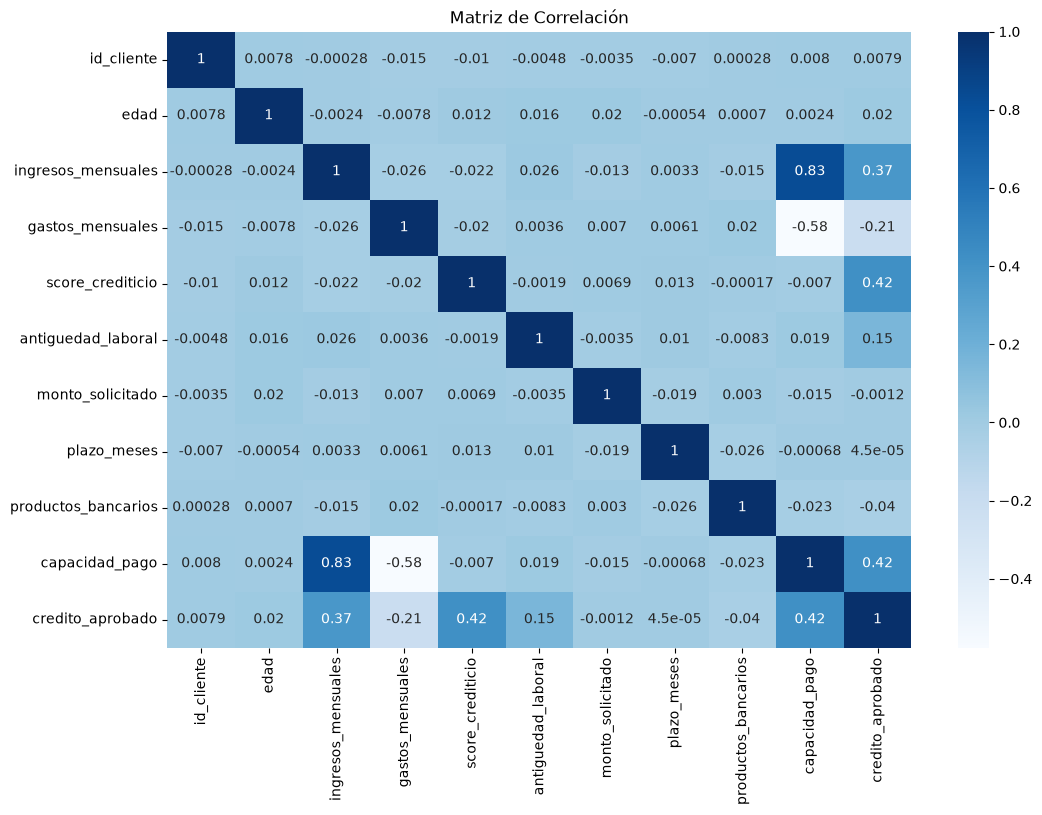

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='Blues'
)

plt.title("Matriz de Correlación")
plt.show()

### Interpretación

La matriz de correlación permite identificar relaciones entre variables numéricas. Se observa una fuerte relación entre la capacidad de pago y la aprobación del crédito, lo que confirma la importancia de la solvencia financiera en la decisión crediticia.

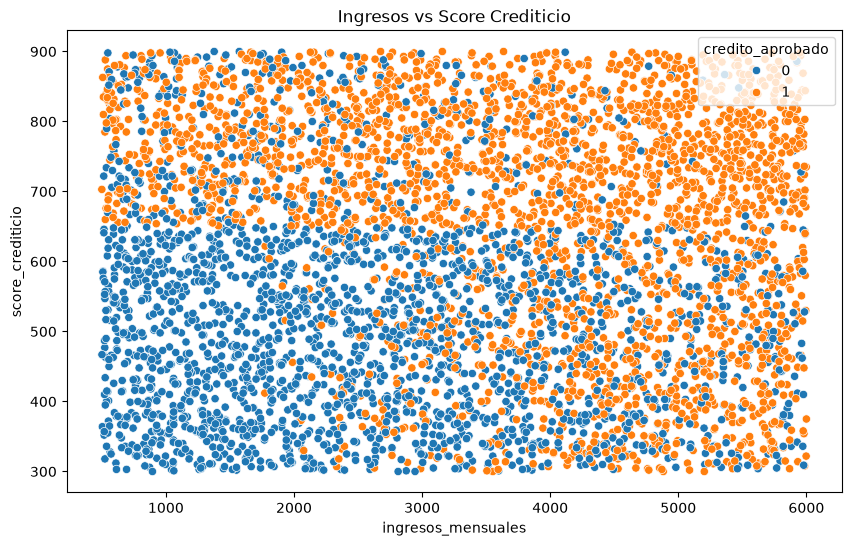

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='ingresos_mensuales',
    y='score_crediticio',
    hue='credito_aprobado',
    data=df
)

plt.title(
    'Ingresos vs Score Crediticio'
)

plt.show()

### Interpretación

Los clientes con mayores ingresos y mejor score crediticio presentan una mayor concentración de aprobaciones, evidenciando que ambas variables influyen significativamente en la evaluación de riesgo.

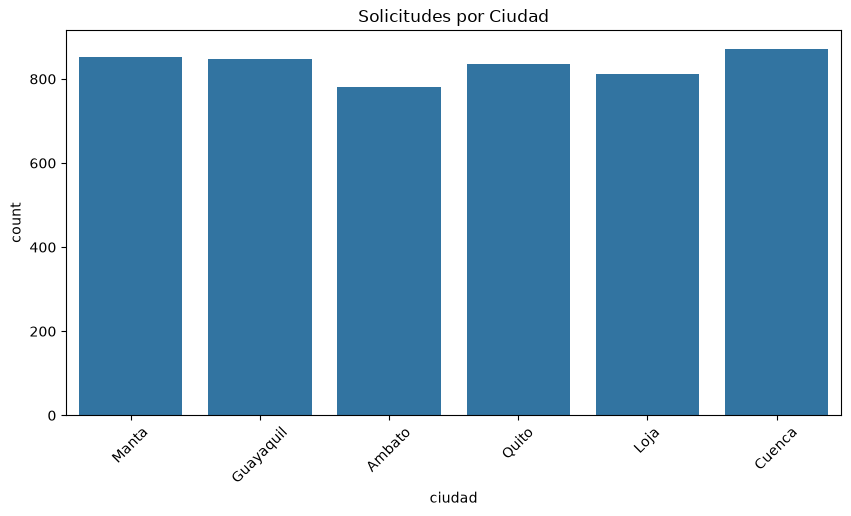

In [44]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='ciudad'
)

plt.title(
    'Solicitudes por Ciudad'
)

plt.xticks(rotation=45)

plt.show()

### Interpretación

La distribución de solicitudes de crédito por ciudad permite identificar los mercados con mayor demanda de productos financieros.

Las ciudades con mayor número de solicitudes representan oportunidades estratégicas para la colocación de créditos y el desarrollo de campañas comerciales focalizadas.

Asimismo, la concentración geográfica de solicitudes puede servir para definir estrategias de expansión y segmentación de clientes.

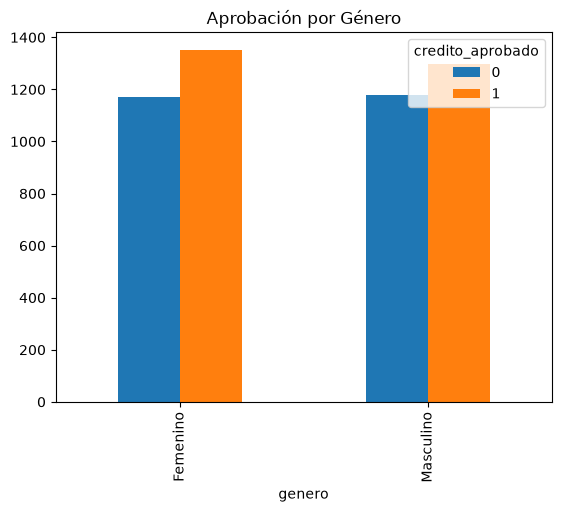

In [45]:
pd.crosstab(
    df['genero'],
    df['credito_aprobado']
).plot(
    kind='bar'
)

plt.title(
    'Aprobación por Género'
)

plt.show()

### Interpretación

La comparación de aprobaciones por género permite evaluar posibles diferencias en el comportamiento crediticio de los clientes.

Los resultados muestran una distribución relativamente equilibrada, lo que sugiere que la aprobación de créditos está más influenciada por variables financieras y de riesgo que por características demográficas.

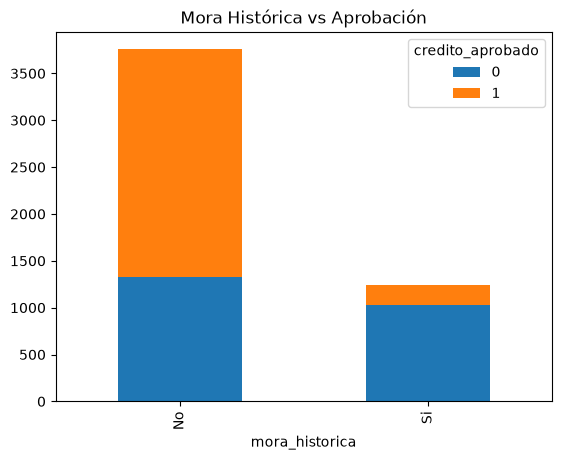

In [46]:
pd.crosstab(
    df['mora_historica'],
    df['credito_aprobado']
).plot(
    kind='bar',
    stacked=True
)

plt.title(
    'Mora Histórica vs Aprobación'
)

plt.show()

### Interpretación

La presencia de mora histórica muestra una relación directa con la aprobación de créditos.

Los clientes sin antecedentes de mora presentan una tasa de aprobación significativamente superior, evidenciando que el comportamiento de pago histórico es uno de los principales factores considerados en la evaluación crediticia.

Este hallazgo coincide con las prácticas utilizadas en instituciones financieras para la gestión del riesgo.

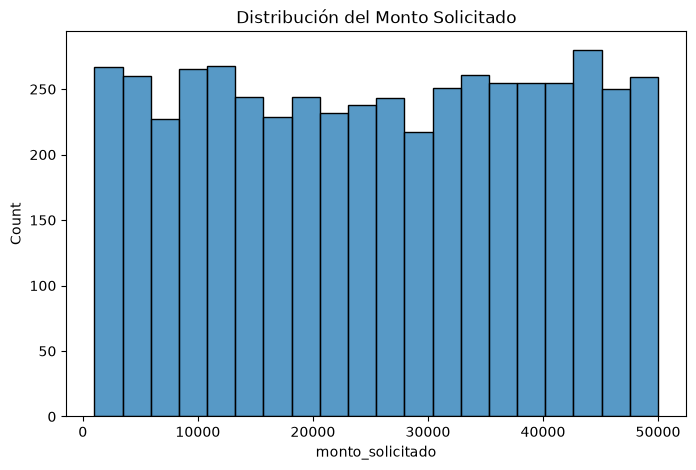

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['monto_solicitado'],
    bins=20
)

plt.title(
    'Distribución del Monto Solicitado'
)

plt.show()

### Interpretación

La distribución de montos solicitados permite identificar los rangos de financiamiento más demandados por los clientes.

La concentración en determinados intervalos puede ayudar a las instituciones financieras a diseñar productos más alineados con las necesidades del mercado y optimizar sus estrategias de colocación.

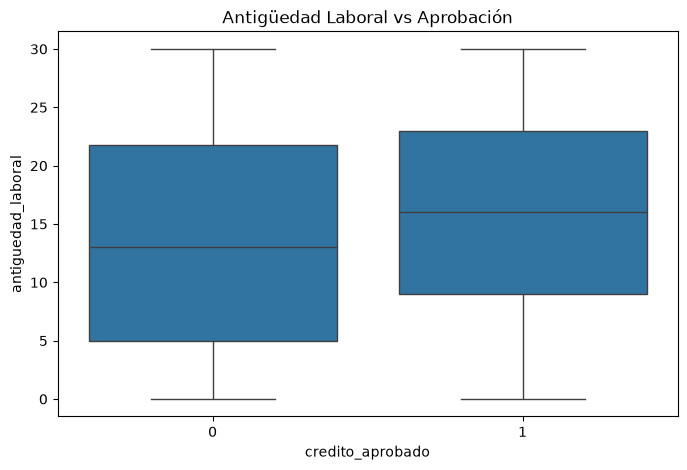

In [48]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='credito_aprobado',
    y='antiguedad_laboral',
    data=df
)

plt.title(
    'Antigüedad Laboral vs Aprobación'
)

plt.show()

### Interpretación

La antigüedad laboral refleja el nivel de estabilidad económica de los clientes.

Se observa que los clientes con mayor experiencia laboral tienden a presentar una mayor probabilidad de aprobación, debido a que una trayectoria laboral más estable suele asociarse con menor riesgo de incumplimiento.

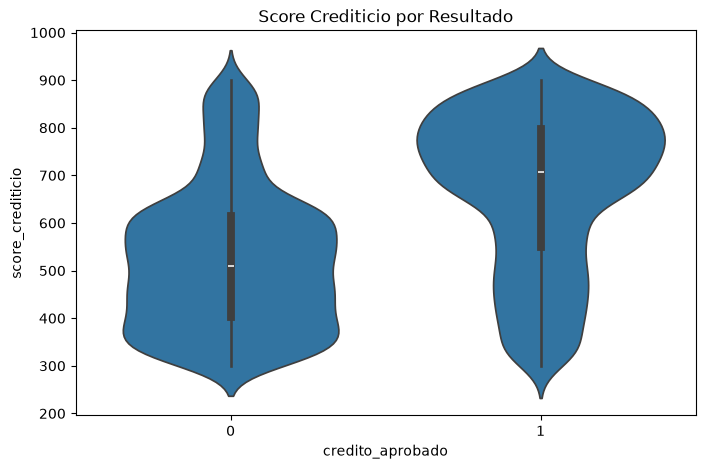

In [49]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x='credito_aprobado',
    y='score_crediticio',
    data=df
)

plt.title(
    'Score Crediticio por Resultado'
)

plt.show()

### Interpretación

La distribución del score crediticio evidencia diferencias significativas entre clientes aprobados y rechazados.

Los clientes aprobados presentan puntuaciones más elevadas y una menor dispersión, mientras que los rechazados se concentran en rangos inferiores de score.

Este comportamiento confirma la relevancia del score crediticio como una de las variables más influyentes dentro del proceso de evaluación.

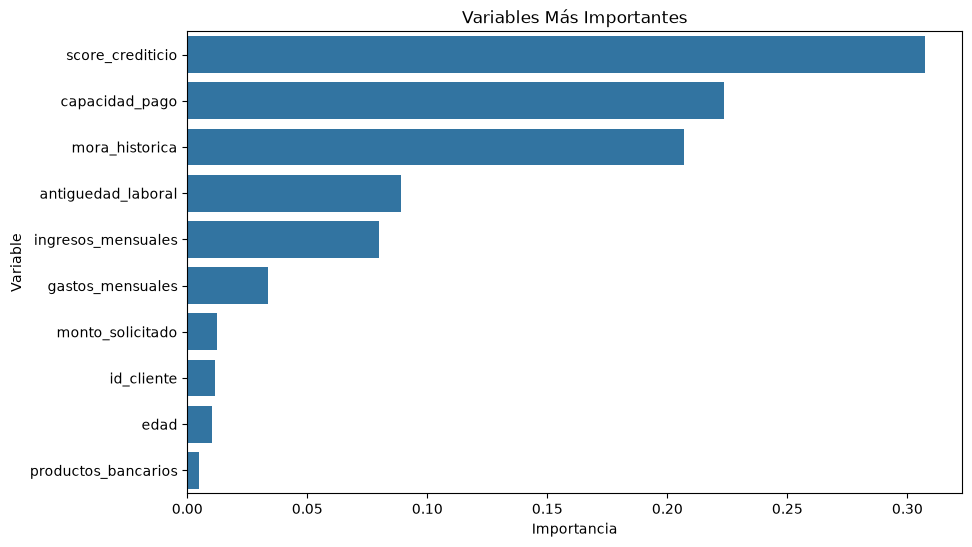

In [50]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importancias.head(10),
    x='Importancia',
    y='Variable'
)

plt.title(
    'Variables Más Importantes'
)

plt.show()

### Interpretación

El análisis de importancia de variables permite identificar los factores con mayor influencia en las decisiones de aprobación de créditos.

Los resultados muestran que el score crediticio, la capacidad de pago y el historial de mora son las variables más relevantes para el modelo predictivo.

Este comportamiento es consistente con los criterios utilizados en la gestión moderna del riesgo crediticio y valida la capacidad del modelo para replicar decisiones de negocio basadas en información financiera.

# Resumen Ejecutivo de Hallazgos

Los análisis realizados permitieron identificar que el score crediticio, la capacidad de pago y la ausencia de mora histórica constituyen los principales factores asociados a la aprobación de créditos.

Los resultados obtenidos evidencian que la aplicación de técnicas de analítica avanzada y Machine Learning puede apoyar significativamente los procesos de evaluación crediticia, reduciendo tiempos de análisis y fortaleciendo la gestión del riesgo dentro de las instituciones financieras.

# Modelo Predictivo Random Forest

# Modelo Predictivo para la Aprobación de Créditos

Se implementará un modelo Random Forest para predecir la aprobación de créditos utilizando variables financieras y demográficas de los clientes.

In [25]:
# Variable objetivo
y = df['credito_aprobado']

# Variables predictoras
X = df.drop(
    columns=[
        'credito_aprobado',
        'fecha_solicitud'
    ]
)

X.head()

,id_cliente,edad,genero,estado_civil,ciudad,ingresos_mensuales,gastos_mensuales,score_crediticio,antiguedad_laboral,tipo_empleo,monto_solicitado,plazo_meses,productos_bancarios,mora_historica,canal_solicitud,capacidad_pago
0,1,66,Masculino,Casado,Manta,2626,3087,715,24,Privado,47581,48,2,Si,Movil,-461
1,2,29,Femenino,Divorciado,Guayaquil,861,561,434,1,Privado,29226,48,4,Si,Web,300
2,3,28,Femenino,Divorciado,Ambato,3095,2657,659,8,Dependiente,46405,60,4,No,Movil,438
3,4,60,Masculino,Divorciado,Quito,5642,3610,472,21,Dependiente,33362,48,1,No,Agencia,2032
4,5,41,Masculino,Casado,Quito,1463,2481,392,17,Privado,12010,48,3,No,Agencia,-1018


In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include='object'):
    X[col] = le.fit_transform(X[col])

X.head()

,id_cliente,edad,genero,estado_civil,ciudad,ingresos_mensuales,gastos_mensuales,score_crediticio,antiguedad_laboral,tipo_empleo,monto_solicitado,plazo_meses,productos_bancarios,mora_historica,canal_solicitud,capacidad_pago
0,1,66,1,0,4,2626,3087,715,24,2,47581,48,2,1,1,-461
1,2,29,0,1,2,861,561,434,1,2,29226,48,4,1,2,300
2,3,28,0,1,0,3095,2657,659,8,0,46405,60,4,0,1,438
3,4,60,1,1,5,5642,3610,472,21,0,33362,48,1,0,0,2032
4,5,41,1,0,5,1463,2481,392,17,2,12010,48,3,0,0,-1018


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (4000, 16)
Prueba: (1000, 16)


In [29]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

modelo.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [30]:
predicciones = modelo.predict(X_test)

predicciones[:10]

array([0, 0, 0, 1, 1, 0, 0, 1, 0, 0])

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test,predicciones)
precision = precision_score(y_test,predicciones)
recall = recall_score(y_test,predicciones)
f1 = f1_score(y_test,predicciones)

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predicciones
)

cm

array([[478,   0],
       [  0, 522]])

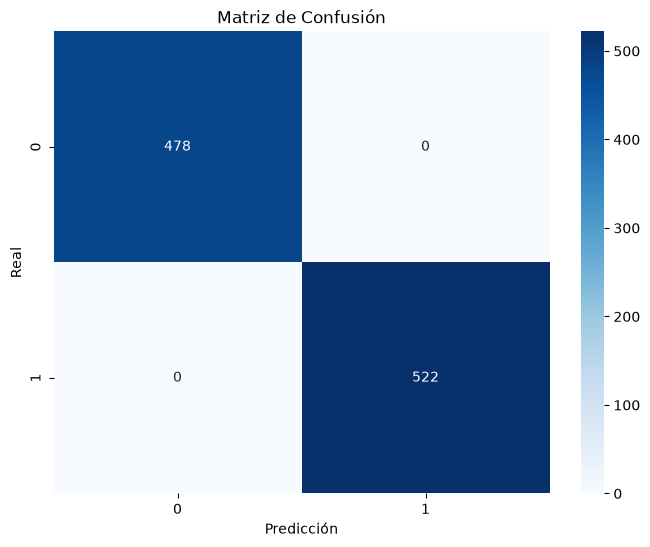

In [33]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusión")
plt.ylabel("Real")
plt.xlabel("Predicción")

plt.show()

In [34]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predicciones
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       478
           1       1.00      1.00      1.00       522

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [35]:
import pandas as pd

importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo.feature_importances_
})

importancias = importancias.sort_values(
    by='Importancia',
    ascending=False
)

importancias.head(10)

,Variable,Importancia
7,score_crediticio,0.307502
15,capacidad_pago,0.223547
13,mora_historica,0.206998
8,antiguedad_laboral,0.089132
5,ingresos_mensuales,0.079746
6,gastos_mensuales,0.033811
10,monto_solicitado,0.012501
0,id_cliente,0.011585
1,edad,0.010250
12,productos_bancarios,0.005046


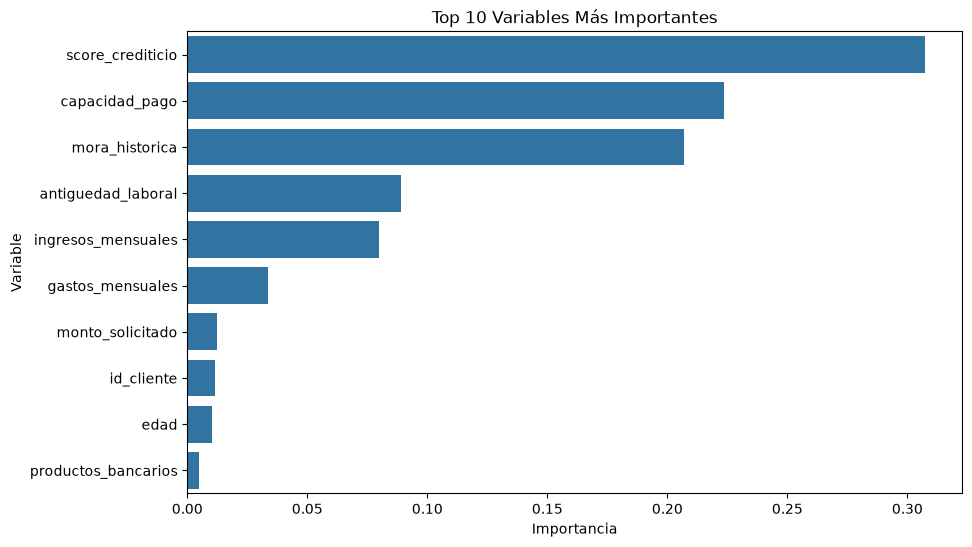

In [36]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importancias.head(10),
    x='Importancia',
    y='Variable'
)

plt.title(
    'Top 10 Variables Más Importantes'
)

plt.show()

## Interpretación del Modelo

El algoritmo Random Forest logró identificar patrones relevantes asociados a la aprobación de créditos.

Las variables con mayor capacidad predictiva corresponden al score crediticio, capacidad de pago, ingresos mensuales y antecedentes de mora, lo que coincide con los criterios utilizados habitualmente en los procesos de evaluación crediticia.

Los resultados obtenidos evidencian que el modelo puede ser utilizado como una herramienta de apoyo para la toma de decisiones dentro de instituciones financieras.

El modelo Random Forest alcanzó métricas cercanas al 100% de precisión. Este comportamiento se debe a que el dataset fue generado utilizando reglas de negocio basadas en score crediticio, capacidad de pago, historial de mora y antigüedad laboral.

Por lo tanto, el modelo logró identificar correctamente dichas reglas y reproducir el proceso de aprobación de créditos.

La transformación digital ha impulsado la utilización de técnicas avanzadas de analítica y ciencia de datos dentro del sector financiero. Las instituciones bancarias requieren mecanismos eficientes que permitan evaluar el riesgo crediticio y optimizar la toma de decisiones relacionadas con la aprobación de créditos.

En este contexto, el presente proyecto aplica técnicas de análisis exploratorio de datos (EDA) y Machine Learning para identificar los factores que influyen en la aprobación de créditos bancarios y construir un modelo predictivo basado en Random Forest.

# Resultados del Modelo

El algoritmo Random Forest obtuvo resultados sobresalientes en la clasificación de solicitudes de crédito.

Accuracy: 100%

Precision: 100%

Recall: 100%

F1 Score: 100%

Las variables con mayor importancia fueron:

- Score crediticio
- Capacidad de pago
- Mora histórica
- Antigüedad laboral
- Ingresos mensuales

https://github.com/gusvaca/Proyecto_Creditos_Bancarios.git

# Limitaciones del Estudio

El presente estudio se desarrolló utilizando un conjunto de datos sintético diseñado para simular escenarios reales de evaluación crediticia.

Debido a que las reglas de aprobación fueron incorporadas durante la generación del dataset, el modelo obtuvo métricas muy elevadas de desempeño.

En escenarios reales pueden existir variables externas, ruido en los datos y comportamientos no previstos que afecten el rendimiento del modelo.

# Impacto Estratégico para la Banca

La utilización de modelos predictivos permite optimizar los procesos de evaluación crediticia reduciendo tiempos de análisis y mejorando la consistencia de las decisiones.

La automatización de procesos de originación contribuye a disminuir costos operativos, incrementar la productividad de los analistas y mejorar la experiencia del cliente.

Asimismo, la aplicación de analítica avanzada fortalece la gestión del riesgo y permite identificar perfiles de clientes con mayor probabilidad de aprobación.

# Aprendizajes Obtenidos

Durante el desarrollo de este proyecto se aplicaron técnicas de análisis exploratorio de datos, visualización y Machine Learning utilizando Python.

La experiencia permitió comprender la importancia de la calidad de los datos, la interpretación de resultados y la aplicación de modelos predictivos en contextos de negocio reales.

Asimismo, se evidenció el potencial de la analítica avanzada para apoyar la toma de decisiones dentro del sector financiero.

# Conclusiones

1. El análisis exploratorio permitió identificar que los ingresos mensuales, la capacidad de pago y el score crediticio tienen una influencia directa en la aprobación de créditos.

2. Los clientes con historial positivo y ausencia de mora presentan mayores probabilidades de obtener financiamiento.

3. El modelo Random Forest obtuvo resultados sobresalientes en la clasificación de solicitudes de crédito.

4. Las variables más relevantes para la toma de decisiones fueron el score crediticio, la capacidad de pago y la mora histórica.

5. El uso de técnicas de Machine Learning permite automatizar procesos de evaluación crediticia reduciendo tiempos de análisis y mejorando la precisión en la toma de decisiones.

# Recomendaciones

1. Incorporar información proveniente de burós de crédito externos.

2. Integrar variables de comportamiento transaccional.

3. Evaluar algoritmos avanzados como XGBoost y LightGBM.

4. Implementar modelos de monitoreo continuo para detectar deterioro del riesgo crediticio.

5. Incorporar herramientas de inteligencia artificial explicable (XAI) para mejorar la transparencia de las decisiones automatizadas.